### データの読み込み

In [2]:
import numpy as np
import json
from Users import GetLabels

user1_ratings, user2_ratings = GetLabels.getLabels()

with open('Restaurants/Features.json', 'r', encoding='utf-8') as f:
    features = json.load(f)

feature_names = [
        "中華", "居酒屋", "ダイニングバー・バル", "和食", 
        "お好み焼き・もんじゃ", "韓国料理", "イタリアン・フレンチ", 
        "焼肉・ホルモン", "洋食", "アジア・エスニック料理", 
        "創作料理", "各国料理", "ラーメン","予算","個室", "喫煙","wifi",
        "カード", "駐車場", "総合評価"
    ]

#numpy形式に変換
features_np = np.array(features)
user1_ratings_np = np.array(user1_ratings)
user2_ratings_np = np.array(user2_ratings)

[1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0]


### 10フォールド交差検証

In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
import japanize_matplotlib

# NumPy配列をリスト形式の文字列に変換する関数
def array_to_list_string(array):
    formatted_array = []
    for elem in array:
        if np.isclose(elem, np.round(elem)):
            # np.iscloseで浮動小数点数が整数に近いか確認し、整数に変換
            formatted_array.append(str(int(np.round(elem))))
        else:
            # 浮動小数点数はそのままの形式で追加
            formatted_array.append(str(elem))
    return '[' + ', '.join(formatted_array) + ']'


# KFoldインスタンスを初期化
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# 各フォールドの正解率を格納するリスト
accuracies = []

# 適合率を格納するリスト
precisions = []
positive_class_ratios = []

# フォールド番号を1から始めるためのカウンター
fold_counter = 1

# KFoldで分割されたインデックスを使ってループ
for train_index, test_index in kf.split(features):
    # トレーニングとテストセットを作成します。
    X_train, X_test = features_np[train_index], features_np[test_index]
    y_train, y_test = user2_ratings_np[train_index], user2_ratings_np[test_index]

    # 決定木の分類器を作成し、トレーニングデータにフィット
    classifier = DecisionTreeClassifier(random_state=0)
    classifier.fit(X_train, y_train)

    # テストデータに対する予測
    predictions = classifier.predict(X_test)

    # 正解率を計算し、リストに追加
    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

    # 適合率を計算し、リストに追加
    precision = precision_score(y_test, predictions)
    precisions.append(precision)
    
    # テストセットに含まれる陽性クラスの割合を計算し、リストに追加
    positive_class_ratio = np.mean(y_test)
    positive_class_ratios.append(positive_class_ratio)

    # 決定木のプロット
    """plt.figure(figsize=(20,10))
    plot_tree(classifier, filled=True, feature_names=feature_names)
    plt.title(f'Decision Tree for Fold {fold_counter}')
    plt.show()"""

    # 正しく予測できなかったインスタンスを出力
    """incorrect_indices = np.where(predictions != y_test)[0]
    print(f'Fold {fold_counter}')
    for index in incorrect_indices:
       # 出力
        print(f'Feature: {array_to_list_string(X_test[index])}')
        print(f'True Label: {y_test[index]}')
        print(f'Predicted Label: {predictions[index]}')
        print("---")"""

    # フォールドの正解率を出力
    print(f'Fold {fold_counter}: Accuracy = {accuracy}')
    
    # 次のフォールドへのカウンターを増やす
    fold_counter += 1

# 全フォールドでの平均正解率を出力
mean_accuracy = np.mean(accuracies)
print(f'\nMean Accuracy across all folds: {mean_accuracy}')

Fold 1: Accuracy = 1.0
Fold 2: Accuracy = 0.9
Fold 3: Accuracy = 0.8
Fold 4: Accuracy = 1.0
Fold 5: Accuracy = 1.0
Fold 6: Accuracy = 0.9
Fold 7: Accuracy = 1.0
Fold 8: Accuracy = 0.9
Fold 9: Accuracy = 1.0
Fold 10: Accuracy = 1.0

Mean Accuracy across all folds: 0.95


### ウィルコクソンの符号順位検定(適合率)
・交差検証の結果を使って, 検定を行った.

In [4]:
from scipy import stats

# 決定木モデルの平均適合率
mean_precision_tree = np.mean(precisions)
print(precisions)
# ランダム手法の平均適合率の計算
mean_precision_random = np.mean([positive_class_ratios])
print(positive_class_ratios)

# 検定の実施
w_stat, p_value = stats.wilcoxon(precisions, positive_class_ratios, alternative='greater')

print(f"決定木モデルの平均適合率: {mean_precision_tree}")
print(f"ランダム手法の平均適合率: {mean_precision_random}")
print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")

[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.3, 0.5, 0.6, 0.4, 0.4, 0.4, 0.6, 0.6, 0.7, 0.3]
決定木モデルの平均適合率: 1.0
ランダム手法の平均適合率: 0.48
検定結果: 統計量 = 55.0, p値 = 0.0009765625


### ウィルコクソンの符号順位検定(正解率)

In [5]:
from scipy import stats

# 決定木モデルの平均適合率
mean_accuracy_tree = np.mean(accuracies)
print(accuracies)
# ランダム手法の平均適合率の計算
accuracy_random = [0.5] * 10
mean_accuracy_random = np.mean(accuracy_random)
print(accuracy_random)

# 検定の実施
w_stat, p_value = stats.wilcoxon(accuracies, accuracy_random, alternative='greater')

print(f"決定木モデルの平均正解率: {mean_accuracy_tree}")
print(f"ランダム手法の平均正解率: {mean_accuracy_random}")
print(f"検定結果: 統計量 = {w_stat}, p値 = {p_value}")

[1.0, 0.9, 0.8, 1.0, 1.0, 0.9, 1.0, 0.9, 1.0, 1.0]
[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]
決定木モデルの平均正解率: 0.95
ランダム手法の平均正解率: 0.5
検定結果: 統計量 = 55.0, p値 = 0.0009765625


### 他の手法との比較

In [6]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold

# モデルの初期化
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "SVM": SVC(random_state=0),
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=500),
    "k-NN": KNeighborsClassifier()
}

# 結果を格納するための辞書
results = {name: {"Accuracy": [], "Precision": [], "Recall": [], "F1": []} for name in models.keys()}

# 各モデルに対して交差検証を行う
for name, model in models.items():
    for train_index, test_index in kf.split(features):
        # トレーニングとテストセットを作成
        X_train, X_test = features_np[train_index], features_np[test_index]
        y_train, y_test = user2_ratings_np[train_index], user2_ratings_np[test_index]

        # モデルを訓練
        model.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = model.predict(X_test)

        # 精度と適合率を計算し、リストに追加
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions)
        recall = recall_score(y_test, predictions)
        f1 = f1_score(y_test, predictions)

        results[name]["Accuracy"].append(accuracy)
        results[name]["Precision"].append(precision)
        results[name]["Recall"].append(recall)
        results[name]["F1"].append(f1)

# 結果の表示
for name, scores in results.items():
    mean_accuracy = np.mean(scores["Accuracy"])
    mean_precision = np.mean(scores["Precision"])
    mean_recall = np.mean(scores["Recall"])
    mean_f1 = np.mean(scores["F1"])
    print(name)
    print(f"Mean Accuracy: {mean_accuracy}, Mean Precision: {mean_precision}, Mean Recall: {mean_recall}, Mean_F1: {mean_f1}\n")


/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/homebrew/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision 

Decision Tree
Mean Accuracy: 0.95, Mean Precision: 1.0, Mean Recall: 0.905, Mean_F1: 0.9455122655122656

SVM
Mean Accuracy: 0.43, Mean Precision: 0.04666666666666667, Mean Recall: 0.13333333333333333, Mean_F1: 0.06837606837606838

Logistic Regression
Mean Accuracy: 0.76, Mean Precision: 0.758095238095238, Mean Recall: 0.7930952380952381, Mean_F1: 0.7510972360972362

k-NN
Mean Accuracy: 0.6, Mean Precision: 0.6028571428571429, Mean Recall: 0.5745238095238095, Mean_F1: 0.5642568542568542



### 訓練データを増やした推移
・各フォールドで訓練データ30, 50, 70, 90と増やし, 正解率と適合率の平均を取ってプロットしている

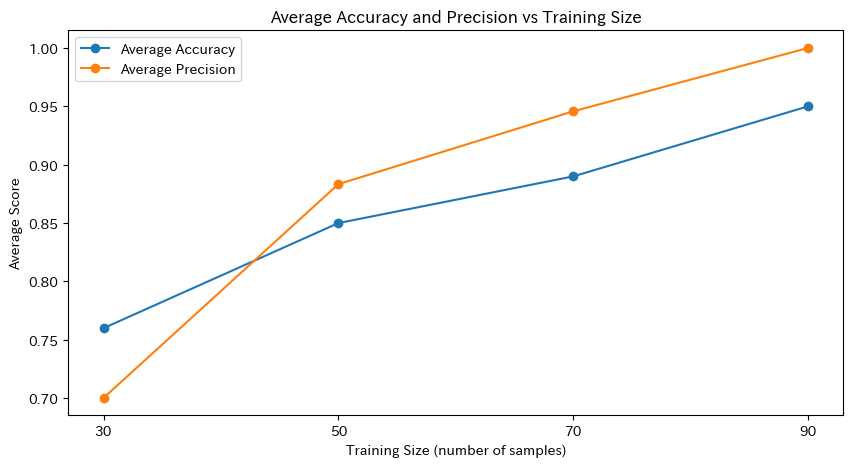

In [7]:
from sklearn.metrics import classification_report
from sklearn.model_selection import KFold

# 指定された訓練データのサイズ
training_sizes = [30, 50, 70, 90]
mean_accuracies = {size: [] for size in training_sizes}
mean_precisions = {size: [] for size in training_sizes}

for train_index, test_index in kf.split(features_np):
    # テストデータを固定
    X_test, y_test = features_np[test_index], user2_ratings_np[test_index]

    for size in training_sizes:
        # 訓練データを指定されたサイズで取得
        X_train = features_np[train_index[:size]]
        y_train = user2_ratings_np[train_index[:size]]

        # モデルを訓練
        classifier = DecisionTreeClassifier(random_state=0)
        classifier.fit(X_train, y_train)

        # テストデータに対する予測
        predictions = classifier.predict(X_test)

        # 正解率と適合率を計算
        accuracy = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions)

        # スコアをリストに追加
        mean_accuracies[size].append(accuracy)
        mean_precisions[size].append(precision)

# 各訓練サイズについて平均スコアを計算
final_accuracies = [np.mean(mean_accuracies[size]) for size in training_sizes]
final_precisions = [np.mean(mean_precisions[size]) for size in training_sizes]

# 正解率と適合率をプロット
plt.figure(figsize=(10, 5))
plt.plot(training_sizes, final_accuracies, label='Average Accuracy', marker='o')
plt.plot(training_sizes, final_precisions, label='Average Precision', marker='o')
plt.xlabel('Training Size (number of samples)')
plt.ylabel('Average Score')
plt.title('Average Accuracy and Precision vs Training Size')
plt.xticks(training_sizes)
plt.legend()
plt.show()


